## 13_ Explainable_AI_with_SHAP
Explainable AI Credit Risk Decision Platform: Integrating Structured Borrower Data, NLP-Driven Text Intelligence, and Macroeconomic Indicators for Transparent Lending Decisions.

#### Reason:
This is why the model predicts default and whether the additional macroeconomic features (Matrix D) contribute meaningfully to those predictions.

In [33]:
# IMPORTS & CONFIGURATION
# ________________________________________

from __future__ import annotations

import gc
import logging
import warnings
from pathlib import Path
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import seaborn as sns

from scipy import sparse

from sklearn.metrics import (
    confusion_matrix,
    classification_report)

# Reproducibility
# ______________________________________

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")

# Project Information
# ______________________________________

PROJECT_NAME = "Explainable AI Credit Risk Decision Platform"

NOTEBOOK_NAME = "13_explainable_ai"

VERSION = "1.0.0"

# Project Directories
# ______________________________________

PROJECT_ROOT = Path.cwd()

FEATURE_STORE_DIR = PROJECT_ROOT / "data" / "feature_store"

MODEL_DIR = PROJECT_ROOT / "models"

REPORT_DIR = PROJECT_ROOT / "reports"

SHAP_DIR = REPORT_DIR / "shap"

SHAP_DIR.mkdir(parents=True, exist_ok=True)

# Display
# _____________________________________________

pd.set_option("display.max_columns", None)

pd.set_option("display.width", 200)

# Banner
# _____________________________________________

print(PROJECT_NAME)

print(f"Notebook : {NOTEBOOK_NAME}")

print(f"Version  : {VERSION}")

print(f"Date     : {datetime.now():%Y-%m-%d %H:%M}")

print("=" * 50)

Explainable AI Credit Risk Decision Platform
Notebook : 13_explainable_ai
Version  : 1.0.0
Date     : 2026-07-21 21:29


In [6]:
# REUSABLE EXPLAINABILITY UTILITIES
# __________________________________________________

# Logger
# _____________________

def get_logger():

    logger = logging.getLogger("Explainability")

    if not logger.handlers:

        logger.setLevel(logging.INFO)

        handler = logging.StreamHandler()

        formatter = logging.Formatter(
            "%(asctime)s | %(levelname)s | %(message)s")

        handler.setFormatter(formatter)

        logger.addHandler(handler)

    return logger

logger = get_logger()

# Banner 
# ____________________________

def section(title):

    logger.info(title)

    logger.info("=" * 50)

In [14]:
# Load model
# _________________________________

def load_model(filename):

    logger.info(f"Loading model: {filename}")

    model = joblib.load(MODEL_DIR / filename)

    logger.info("Model loaded successfully.")

    return model


# Load sparse matrix
# _________________________________

def load_sparse_matrix(filename):

    logger.info(f"Loading {filename}")

    matrix = sparse.load_npz(FEATURE_STORE_DIR / filename)

    logger.info("Matrix loaded successfully.")

    return matrix
    
# Load Target
# _________________________________

def load_target():

    y_test = y_test = np.load(FEATURE_STORE_DIR / "y_test.npy")

    return y_test

# Load Feature Names
# _________________________________

def load_feature_names(filename):

    feature_df = pd.read_csv(FEATURE_STORE_DIR / filename)

    return feature_df["Feature_Name"].tolist()

In [19]:
# Randomly sample observations for SHAP analysis.
# ___________________________________________________________________

def sample_for_shap(X,y,sample_size=5000,random_state=42):

    rng = np.random.default_rng(random_state)

    sample_size = min(sample_size, X.shape[0])

    indices = rng.choice(X.shape[0],size=sample_size,replace=False)

    X_sample = X[indices]

    # Support both pandas Series and NumPy arrays
    
    if isinstance(y, pd.Series):

        y_sample = y.iloc[indices]

    else:

        y_sample = y[indices]

    return X_sample, y_sample, indices

In [9]:
# save figure
# ________________________________________

def save_figure(filename):

    path = SHAP_DIR / filename

    plt.savefig(path,dpi=300,bbox_inches="tight")

    logger.info(f"Saved: {filename}")

# Export Table
# ___________________________________________

def export_table(df, filename):

    path = SHAP_DIR / filename

    df.to_csv(path, index=False)

    logger.info(f"Saved: {filename}")

# Memory cleanup
# _______________________________________________

def clear_memory(*objects):

    for obj in objects:

        del obj

    gc.collect()

    logger.info("Memory released.")

In [16]:
# LOAD CHAMPION MODEL
# _____________________________________________________

section("Load Champion Model")

champion_model = load_model("champion_xgboost.pkl")

logger.info(type(champion_model))

# LOAD MATRIX D
# ________________________________________________________

section("Load Matrix D")

matrix_D_test = load_sparse_matrix("matrix_D_test.npz")

y_test = load_target()

logger.info(f"Matrix Shape : {matrix_D_test.shape}")

logger.info(f"Target Shape : {y_test.shape}")

assert matrix_D_test.shape[0] == len(y_test)

logger.info("Dataset validation passed.")

# LOAD FEATURE NAMES
# ___________________________________________________________

section("Load Matrix D Feature Names")

feature_names = load_feature_names("matrix_D_feature_names.csv")

logger.info(f"Total Features : {len(feature_names)}")

feature_summary = pd.DataFrame({"Feature Number": range(1, len(feature_names)+1),

    "Feature Name": feature_names})

display(feature_summary.head(15))

2026-07-21 18:57:10,789 | INFO | Load Champion Model
2026-07-21 18:57:10,791 | INFO | ==================================================
2026-07-21 18:57:10,791 | INFO | Loading model: champion_xgboost.pkl
2026-07-21 18:57:10,811 | INFO | Model loaded successfully.
2026-07-21 18:57:10,812 | INFO | <class 'xgboost.sklearn.XGBClassifier'>
2026-07-21 18:57:10,812 | INFO | Load Matrix D
2026-07-21 18:57:10,813 | INFO | ==================================================
2026-07-21 18:57:10,813 | INFO | Loading matrix_D_test.npz
2026-07-21 18:57:10,878 | INFO | Matrix loaded successfully.
2026-07-21 18:57:10,882 | INFO | Matrix Shape : (100000, 91)
2026-07-21 18:57:10,882 | INFO | Target Shape : (100000,)
2026-07-21 18:57:10,883 | INFO | Dataset validation passed.
2026-07-21 18:57:10,883 | INFO | Load Matrix D Feature Names
2026-07-21 18:57:10,883 | INFO | ==================================================
2026-07-21 18:57:11,013 | INFO | Total Features : 91


,Feature Number,Feature Name
0,1,numeric__loan_amnt
1,2,numeric__int_rate
2,3,numeric__annual_inc
3,4,numeric__dti
4,5,numeric__revol_util
5,6,categorical__grade_A
6,7,categorical__grade_B
7,8,categorical__grade_C
8,9,categorical__grade_D
9,10,categorical__grade_E


In [20]:
# CREATE SHAP EXPLAINER
# ____________________________________________________

section("Create SHAP Explainer")

logger.info("Sampling observations for SHAP analysis...")

matrix_D_shap, y_shap, shap_indices = sample_for_shap(
    
    matrix_D_test,
    
    y_test,
    
    sample_size=5000,
    
    random_state=RANDOM_STATE)

logger.info(f"Sample Shape : {matrix_D_shap.shape}")

logger.info("Creating SHAP Explainer...")

explainer = shap.Explainer(champion_model)

logger.info("Computing SHAP values...")

shap_values = explainer(matrix_D_shap)

logger.info("SHAP values computed successfully.")

2026-07-21 20:47:53,756 | INFO | Create SHAP Explainer
2026-07-21 20:47:53,759 | INFO | ==================================================
2026-07-21 20:47:53,762 | INFO | Sampling observations for SHAP analysis...
2026-07-21 20:47:53,910 | INFO | Sample Shape : (5000, 91)
2026-07-21 20:47:53,910 | INFO | Creating SHAP Explainer...
2026-07-21 20:47:54,030 | INFO | Computing SHAP values...
2026-07-21 20:47:54,142 | INFO | SHAP values computed successfully.


#### Global Feature Importance (SHAP Summary Plot)
##### ___________________________________________________

2026-07-21 20:52:14,985 | INFO | Global Feature Importance
2026-07-21 20:52:14,987 | INFO | ==================================================
2026-07-21 20:52:17,506 | INFO | Saved: shap_summary_plot.png


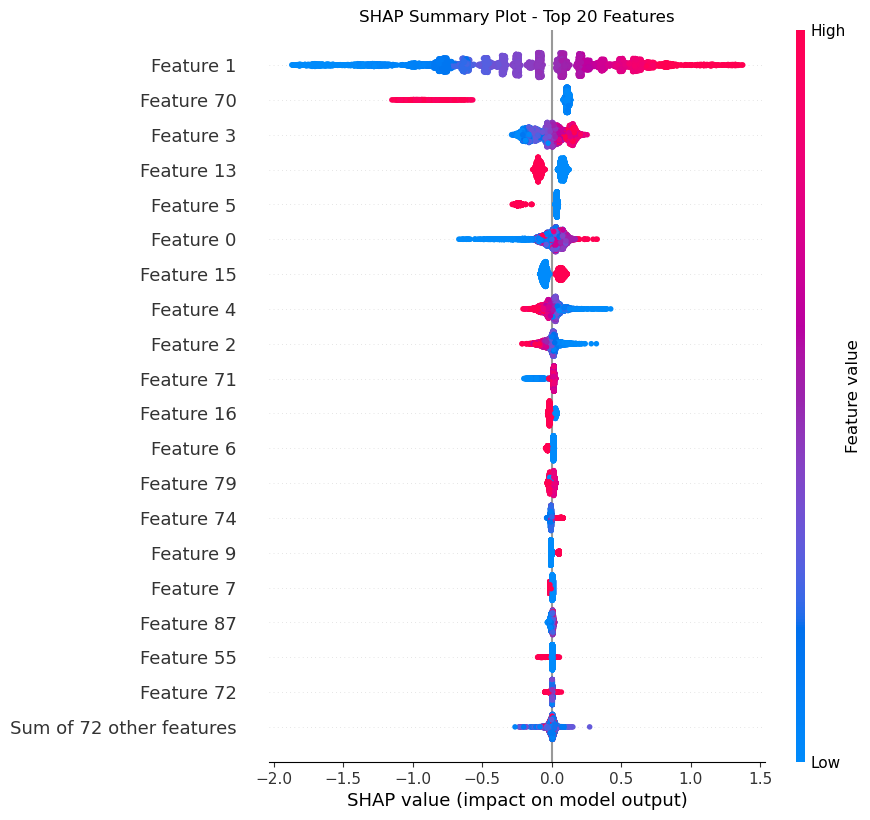

2026-07-21 20:52:18,202 | INFO | Summary plot generated.


In [21]:
# SHAP SUMMARY PLOT
# _____________________________________________

section("Global Feature Importance")

plt.figure(figsize=(12,8))

shap.plots.beeswarm(shap_values,max_display=20,show=False)

plt.title("SHAP Summary Plot - Top 20 Features")

save_figure("shap_summary_plot.png")

plt.show()

logger.info("Summary plot generated.")

In [22]:
# FEATURE IMPORTANCE RANKING
# ________________________________________________________

section("Feature Importance Ranking")

importance = np.abs(shap_values.values).mean(axis=0)

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Mean_SHAP": importance})

importance_df = (importance_df.sort_values(

        "Mean_SHAP",

        ascending=False)

    .reset_index(drop=True))

importance_df.insert(0,"Rank",range(1,len(importance_df)+1))

display(importance_df.head(20))

export_table(importance_df,"feature_importance.csv")

2026-07-21 20:53:54,485 | INFO | Feature Importance Ranking
2026-07-21 20:53:54,487 | INFO | ==================================================


,Rank,Feature,Mean_SHAP
0,1,numeric__int_rate,0.548353
1,2,FEDFUNDS,0.237171
2,3,numeric__dti,0.100610
3,4,categorical__home_ownership_MORTGAGE,0.086227
4,5,categorical__grade_A,0.073028
5,6,numeric__loan_amnt,0.070188
6,7,categorical__home_ownership_RENT,0.058405
7,8,numeric__revol_util,0.047799
8,9,numeric__annual_inc,0.039195
9,10,UNRATE,0.030061


2026-07-21 20:53:54,552 | INFO | Saved: feature_importance.csv


Top 20 SHAP Feature Importance


2026-07-21 21:42:03,376 | INFO | Saved: top20_shap_feature_importance.png


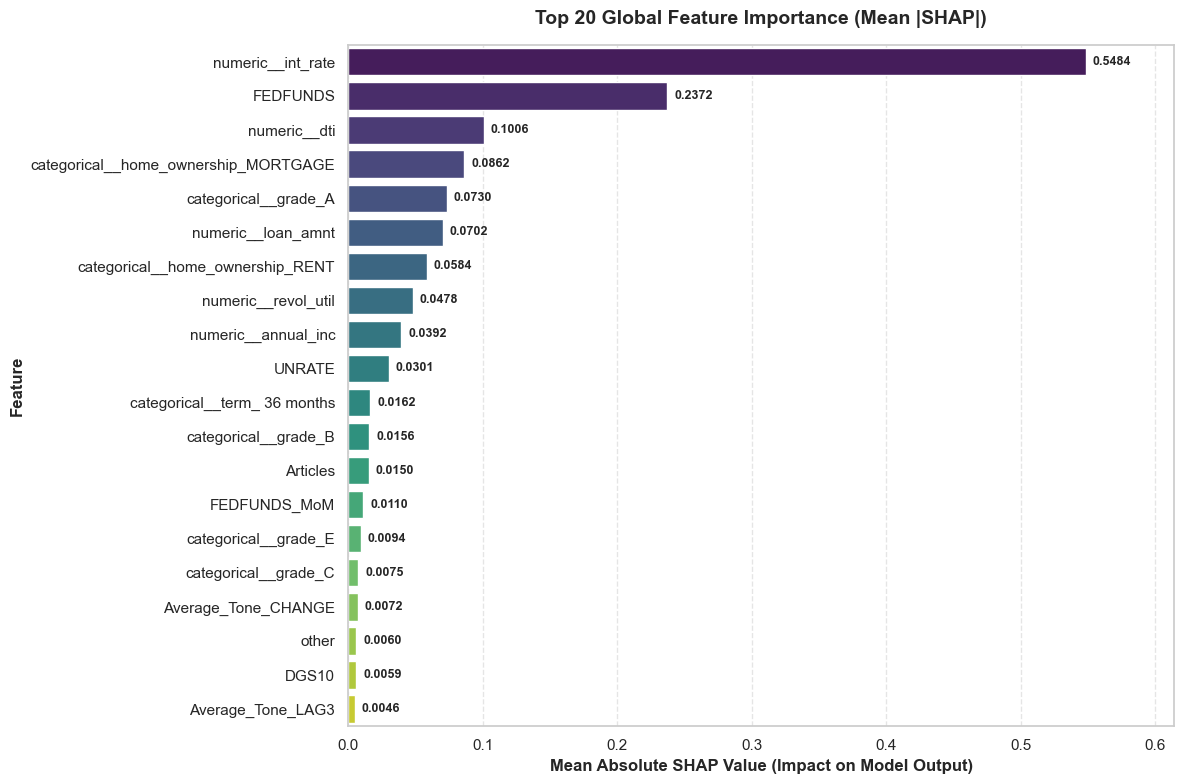

2026-07-21 21:42:03,525 | INFO | Saved: top20_shap_features.csv
2026-07-21 21:42:03,525 | INFO | Top 20 SHAP feature table exported.


In [38]:
# TOP 20 SHAP FEATURE IMPORTANCE BAR CHART
# ___________________________________________________________

print("Top 20 SHAP Feature Importance")

# Select Top 20 Features

top20_importance = importance_df.head(20).copy()

top20_importance = top20_importance.sort_values("Mean_SHAP", ascending=False)

# Plot

plt.figure(figsize=(12, 8))

# Create a colorful gradient palette

palette = sns.color_palette("viridis", n_colors=len(top20_importance))

ax = sns.barplot(
    
    data=top20_importance,
    
    x="Mean_SHAP",
    
    y="Feature",
    
    palette=palette)

# Add exact numeric annotations

for p in ax.patches:
    
    width = p.get_width()
    
    ax.annotate(
        
        f'{width:.4f}', 
        
        (width, p.get_y() + p.get_height() / 2.), 
        
         ha='left', va='center', 
        
    fontsize=9, fontweight='bold', 
        
    xytext=(5, 0), textcoords='offset points')

# Formatting

plt.title("Top 20 Global Feature Importance (Mean |SHAP|)", fontsize=14, fontweight="bold", pad=15)

plt.xlabel("Mean Absolute SHAP Value (Impact on Model Output)", fontsize=12, fontweight="bold")

plt.ylabel("Feature", fontsize=12, fontweight="bold")

# Expand X-axis slightly 

plt.xlim(0, top20_importance["Mean_SHAP"].max() * 1.12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

# Save Figure
 
save_figure("top20_shap_feature_importance.png")

plt.show()

# Export Top 20 Features

export_table(importance_df.head(20),
             
             "top20_shap_features.csv")

logger.info("Top 20 SHAP feature table exported.")

In [41]:
# FEATURE SOURCE ATTRIBUTION
# ______________________________________________________

print("Feature Source Attribution")

# Feature Groups
# _________________________________________________

STRUCTURED_FEATURES = {

    "loan_amnt",
    "term",
    "grade",
    "int_rate",
    "annual_inc",
    "dti",
    "home_ownership",
    "revol_util",
    "emp_length",
    "verification_status",
    "title",
    "fico_range_low",
    "fico_range_high",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "total_acc",
    "mort_acc"}

FRED_FEATURES = {

    "FEDFUNDS",
    "UNRATE",
    "CPIAUCSL",
    "DGS10",
    "DGS2",
    "MORTGAGE30US",
    "UMCSENT",
    "GDPC1",
    "FEDFUNDS_MoM",
    "FEDFUNDS_3M_MA",
    "UNRATE_6M_MA",
    "CPIAUCSL_YoY",
    "CPIAUCSL_3M_Momentum",
    "MORTGAGE30US_3M_MA",
    "UMCSENT_3M_MA",
    "GDPC1_Growth",
    "YIELD_CURVE"}

GDELT_FEATURES = {

    "Articles",
    "BANK",
    "BANKRUPTCY",
    "LOAN",
    "CREDIT",
    "DEBT",
    "DEFAULT",
    "MORTGAGE",
    "HOUSING",
    "EMPLOYMENT",
    "UNEMPLOYMENT",
    "INFLATION",
    "RECESSION",
    "INTEREST_RATE",
    "FEDERAL_RESERVE",
    "ECONOMY",
    "Average_Tone"}

Feature Source Attribution


In [42]:
# feature classification

def classify_feature(feature):

    if feature in STRUCTURED_FEATURES:
        return "Structured"

    elif feature in FRED_FEATURES:
        return "FRED"

    elif feature in GDELT_FEATURES:
        return "GDELT"

    else:
        return "TF-IDF NLP"

In [53]:
# Building Attribution table
# ________________________________________________

importance_df["Feature_Source"] = (

    importance_df["Feature"]

    .apply(classify_feature))

display(importance_df.head(20))

# Export features

export_table(importance_df,"feature_source_attribution.csv")

logger.info("Feature source attribution exported.")

,Rank,Feature,Mean_SHAP,Feature_Source
0,1,numeric__int_rate,0.548353,TF-IDF NLP
1,2,FEDFUNDS,0.237171,FRED
2,3,numeric__dti,0.100610,TF-IDF NLP
3,4,categorical__home_ownership_MORTGAGE,0.086227,TF-IDF NLP
4,5,categorical__grade_A,0.073028,TF-IDF NLP
5,6,numeric__loan_amnt,0.070188,TF-IDF NLP
6,7,categorical__home_ownership_RENT,0.058405,TF-IDF NLP
7,8,numeric__revol_util,0.047799,TF-IDF NLP
8,9,numeric__annual_inc,0.039195,TF-IDF NLP
9,10,UNRATE,0.030061,FRED


2026-07-22 00:20:34,090 | INFO | Saved: feature_source_attribution.csv
2026-07-22 00:20:34,090 | INFO | Feature source attribution exported.


In [54]:
# FEATURE SOURCE CONTRIBUTION
# ______________________________________________________

section("Contribution by Feature Source")

source_summary = (

    importance_df

    .groupby("Feature_Source")

    .agg(

        Number_of_Features=("Feature","count"),

        Total_SHAP=("Mean_SHAP","sum"),

        Average_SHAP=("Mean_SHAP","mean"))

    .sort_values(

        "Total_SHAP",

        ascending=False)

    .reset_index())

display(source_summary)

# Export 

export_table(source_summary,"feature_group_contribution.csv")

2026-07-22 00:20:53,954 | INFO | Contribution by Feature Source
2026-07-22 00:20:53,956 | INFO | ==================================================


,Feature_Source,Number_of_Features,Total_SHAP,Average_SHAP
0,TF-IDF NLP,76,1.112669,0.014640
1,FRED,9,0.293854,0.032650
2,GDELT,6,0.026200,0.004367


2026-07-22 00:20:53,984 | INFO | Saved: feature_group_contribution.csv


2026-07-21 21:59:52,922 | INFO | Saved: feature_group_contribution.png


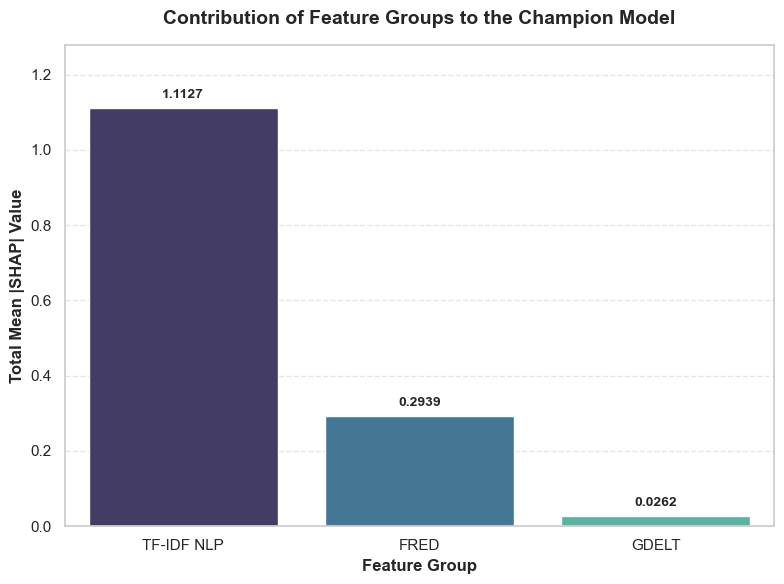

In [46]:
# Plot feature source
# ___________________________________________________

plt.figure(figsize=(8, 6))

sns.set_theme(style="whitegrid")

# Sort by Total_SHAP 

plot = source_summary.sort_values("Total_SHAP",
                                  
                                  ascending=False).reset_index(drop=True)

# Apply a vibrant palette 

palette = sns.color_palette("mako", n_colors=len(plot))

ax = sns.barplot(data=plot,
                 
                 x="Feature_Source",
                 
                 y="Total_SHAP",
                 
                 palette=palette)

# Add exact numeric value annotations on top of each bar

for p in ax.patches:
    
    height = p.get_height()
    
    ax.annotate(
        
        f'{height:.4f}', 
        
        (p.get_x() + p.get_width() / 2., height),
        
        ha='center', va='bottom', 

        fontsize=10, fontweight='bold', 

        xytext=(0, 5), textcoords='offset points')

# Formatting

plt.title(
    
    "Contribution of Feature Groups to the Champion Model",
    
    fontweight="bold", pad=15)

plt.ylabel("Total Mean |SHAP| Value", fontsize=12, fontweight="bold")

plt.xlabel("Feature Group", fontsize=12, fontweight="bold")

# Expand Y-axis 

plt.ylim(0, plot["Total_SHAP"].max() * 1.15)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

# Save Figure
# ____________________________________________________
save_figure("feature_group_contribution.png")

plt.show()

2026-07-21 21:02:05,873 | INFO | SHAP Dependence Plots
2026-07-21 21:02:05,875 | INFO | ==================================================
2026-07-21 21:02:05,877 | INFO | Top Features : ['numeric__int_rate', 'FEDFUNDS', 'numeric__dti']
2026-07-21 21:02:06,513 | INFO | Saved: numeric__int_rate_dependence.png


<Figure size 800x600 with 0 Axes>

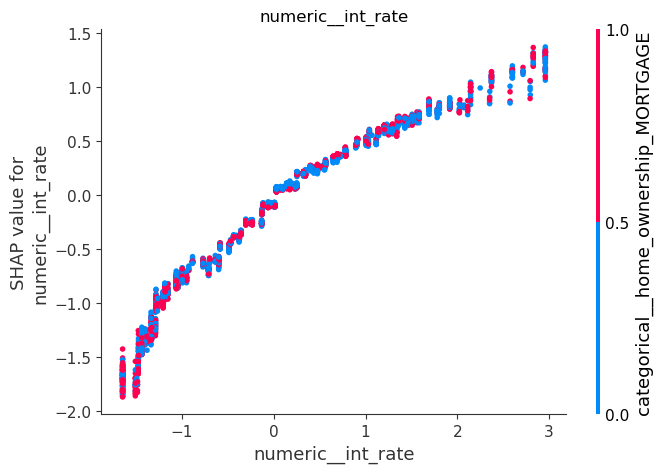

2026-07-21 21:02:07,298 | INFO | Saved: FEDFUNDS_dependence.png


<Figure size 800x600 with 0 Axes>

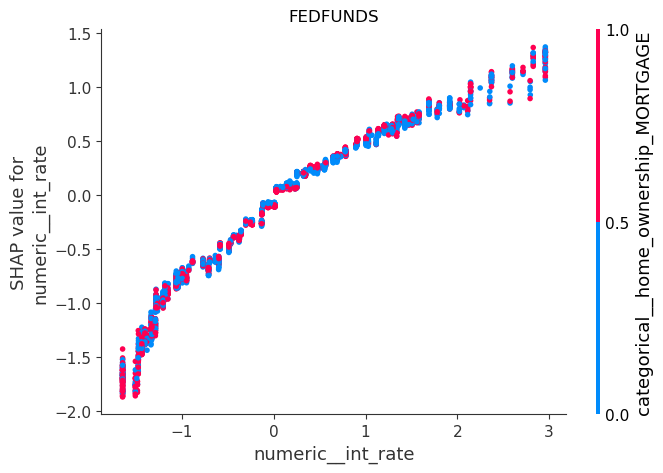

2026-07-21 21:02:08,004 | INFO | Saved: numeric__dti_dependence.png


<Figure size 800x600 with 0 Axes>

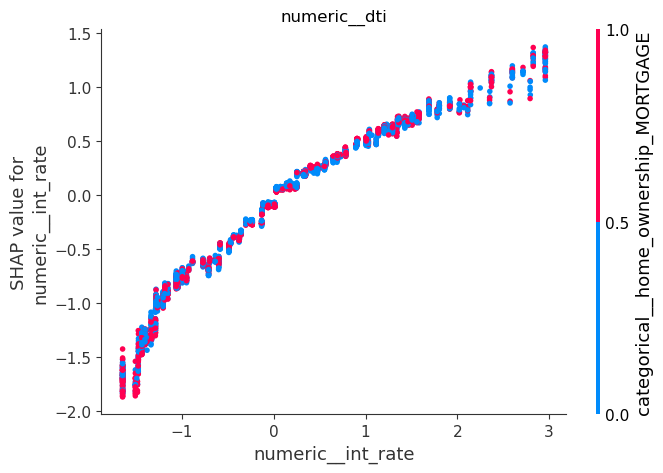

In [26]:
# DEPENDENCE PLOTS
# ________________________________________________________

section("SHAP Dependence Plots")

feature_idx = feature_names.index(feature)

top_features = importance_df.head(3)["Feature"].tolist()

logger.info(f"Top Features : {top_features}")

for feature in top_features:

    plt.figure(figsize=(8,6))

    shap.dependence_plot(
    
        feature_idx,
    
        shap_values.values,
    
        matrix_D_shap.toarray(),
    
        feature_names=feature_names,
    
        show=False)

    plt.title(feature)

    filename = (

        feature

        .replace("/","_")

        .replace(" ","_")

        + "_dependence.png")

    save_figure(filename)

    plt.show()

Local Explainability


2026-07-21 21:12:52,229 | INFO | Saved: True_Positive.png


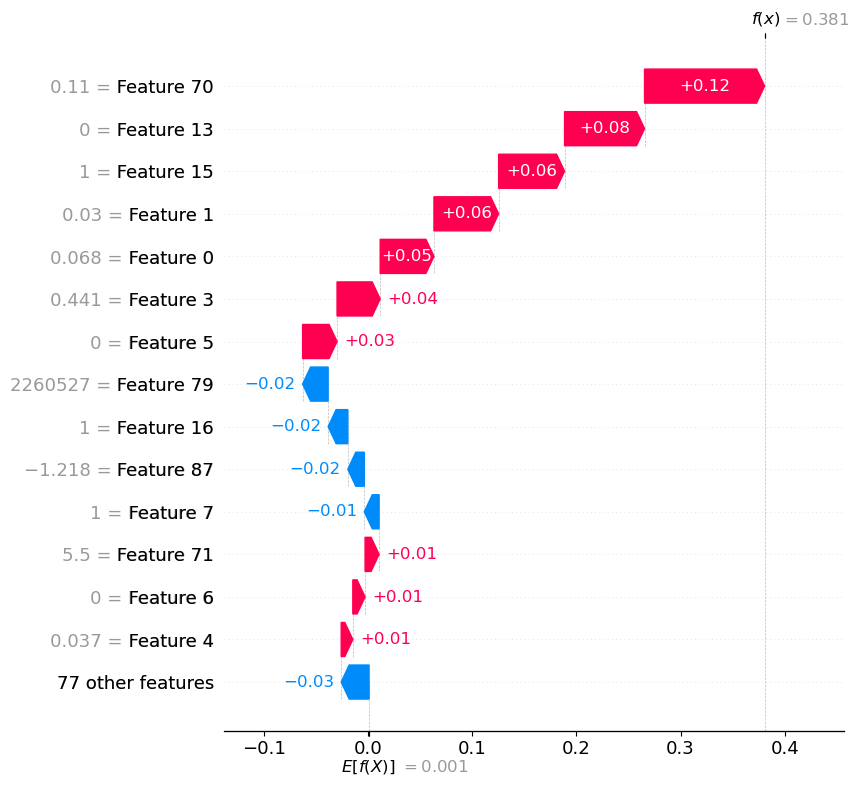

2026-07-21 21:12:52,910 | INFO | Saved: True_Negative.png


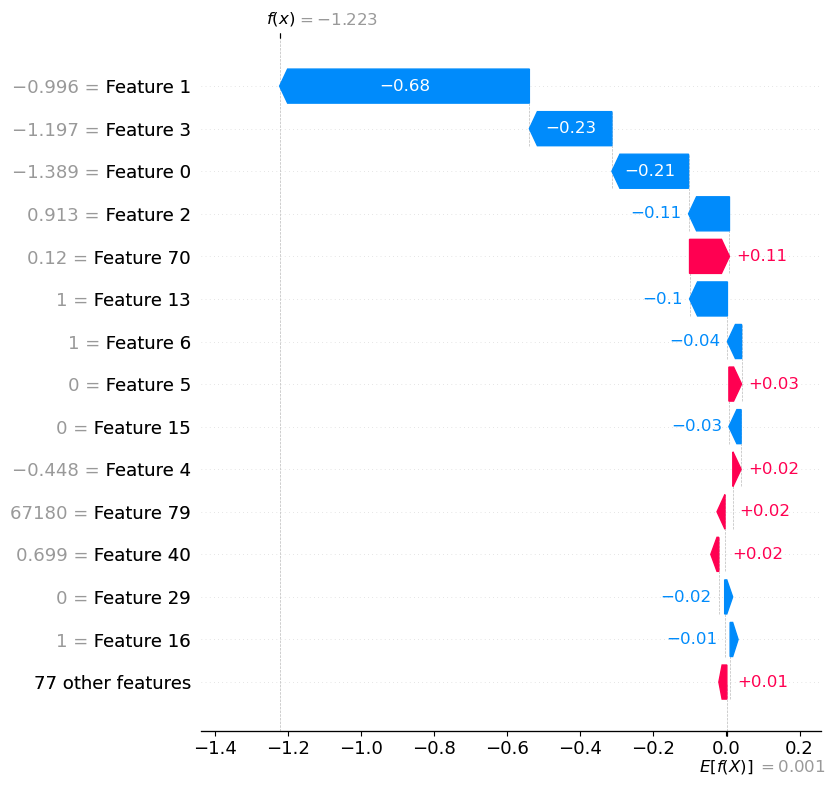

2026-07-21 21:12:53,586 | INFO | Saved: False_Positive.png


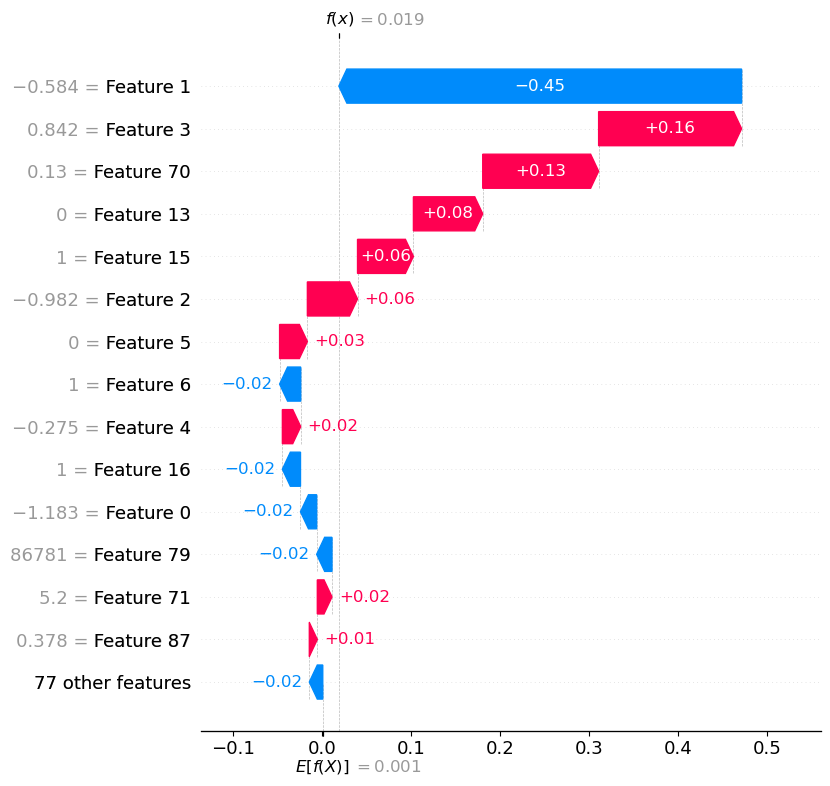

2026-07-21 21:12:54,479 | INFO | Saved: False_Negative.png


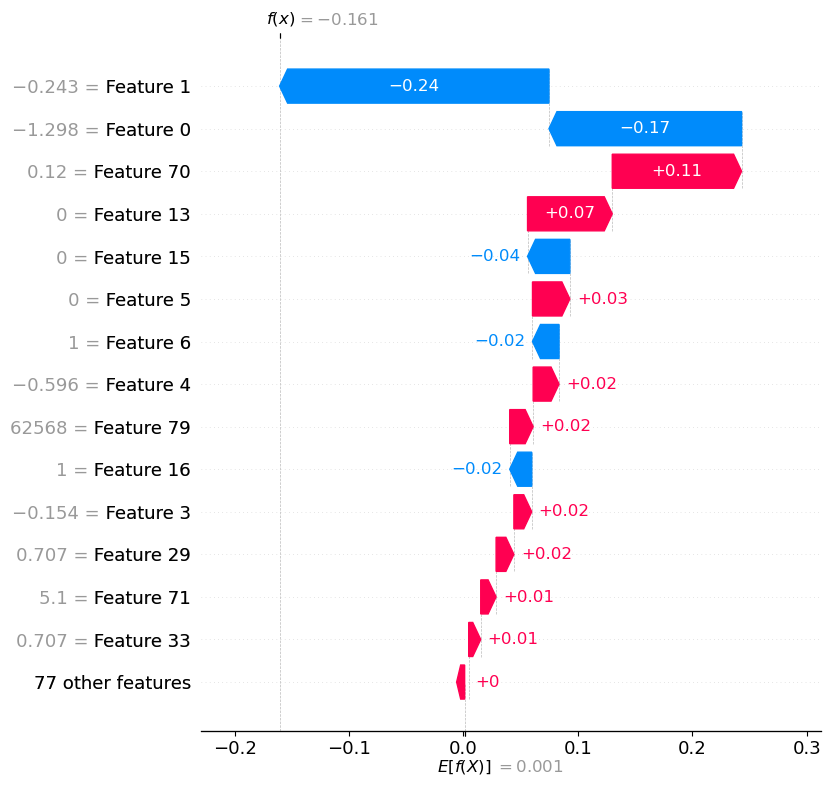

2026-07-21 21:12:54,596 | INFO | Local explainability reports generated.


In [29]:
# LOCAL EXPLANATIONS
# ____________________________________________________

print("Local Explainability")

predictions = champion_model.predict(matrix_D_shap)

# Convert target to NumPy if needed

y_true = np.asarray(y_shap)

cases = {

    "True_Positive":
        np.where((predictions == 1) & (y_true == 1))[0][0],

    "True_Negative":
        np.where((predictions == 0) & (y_true == 0))[0][0],

    "False_Positive":
        np.where((predictions == 1) & (y_true == 0))[0][0],

    "False_Negative":
        np.where((predictions == 0) & (y_true == 1))[0][0],}

for name, idx in cases.items():

    plt.figure(figsize=(10,6))

    shap.plots.waterfall(
        
        shap_values[idx],
        
        max_display=15,
        
        show=False)

    save_figure(f"{name}.png")

    plt.show()

logger.info("Local explainability reports generated.")

In [30]:
# EXECUTIVE REPORT
# _________________________________________________________

print("Executive Explainability Report")

report = pd.DataFrame({

    "Item":[

        "Champion Model",

        "Feature Set",

        "Total Features",

        "Top Feature",

        "Second Feature",

        "Third Feature",

        "SHAP Sample Size"],

    "Value":[

        "Optimised XGBoost",

        "Matrix D",

        len(feature_names),

        top_features[0],

        top_features[1],

        top_features[2],

        matrix_D_shap.shape[0]]})

display(report)

export_table(report,"executive_explainability_report.csv")

Executive Explainability Report


,Item,Value
0,Champion Model,Optimised XGBoost
1,Feature Set,Matrix D
2,Total Features,91
3,Top Feature,numeric__int_rate
4,Second Feature,FEDFUNDS
5,Third Feature,numeric__dti
6,SHAP Sample Size,5000


2026-07-21 21:15:15,387 | INFO | Saved: executive_explainability_report.csv


In [48]:
# SECTION 12 - EXPORT REPORTS
# ___________________________________________________

print("Export Reports")

files = sorted(SHAP_DIR.glob("*"))

summary = pd.DataFrame({

    "File":[f.name for f in files],

    "Size (KB)":[round(f.stat().st_size/1024,2) for f in files]})

display(summary)

logger.info(f"Total Reports Generated : {len(summary)}")

logger.info("Explainability pipeline completed successfully.")

Export Reports


,File,Size (KB)
0,.ipynb_checkpoints,0.22
1,FEDFUNDS_dependence.png,180.43
2,False_Negative.png,253.61
3,False_Positive.png,260.09
4,True_Negative.png,258.62
5,True_Positive.png,253.99
6,executive_explainability_report.csv,0.18
7,feature_group_contribution.png,104.38
8,feature_importance.csv,2.09
9,numeric__dti_dependence.png,180.38


2026-07-22 00:06:34,371 | INFO | Total Reports Generated : 14
2026-07-22 00:06:34,371 | INFO | Explainability pipeline completed successfully.


In [49]:
# EXECUTIVE EXPLAINABILITY REPORT
# __________________________________________________________

print("Executive Explainability Report")

logger.info("Building explainability summary...")

report = pd.DataFrame({

    "Metric":[

        "Champion Model",

        "Feature Matrix",

        "Total Features",

        "SHAP Sample Size",

        "Top Feature",

        "Second Feature",

        "Third Feature",

        "Most Influential Feature Group"],

    "Value":[

        "Optimised XGBoost",

        "Matrix D",

        len(feature_names),

        matrix_D_shap.shape[0],

        importance_df.iloc[0]["Feature"],

        importance_df.iloc[1]["Feature"],

        importance_df.iloc[2]["Feature"],

        source_summary.iloc[0]["Feature_Source"]]})

display(report)

export_table(report,"executive_explainability_report.csv")

logger.info("Executive report generated successfully.")

2026-07-22 00:13:58,562 | INFO | Building explainability summary...


Executive Explainability Report


,Metric,Value
0,Champion Model,Optimised XGBoost
1,Feature Matrix,Matrix D
2,Total Features,91
3,SHAP Sample Size,5000
4,Top Feature,numeric__int_rate
5,Second Feature,FEDFUNDS
6,Third Feature,numeric__dti
7,Most Influential Feature Group,TF-IDF NLP


2026-07-22 00:13:58,609 | INFO | Saved: executive_explainability_report.csv
2026-07-22 00:13:58,609 | INFO | Executive report generated successfully.


In [50]:
# AUTOMATED INTERPRETATION
# __________________________________________________

top_feature = importance_df.iloc[0]["Feature"]

top_group = source_summary.iloc[0]["Feature_Source"]

summary_text = f"""
Champion Model : Optimised XGBoost

Feature Set : Matrix D

The most influential predictor was '{top_feature}'.

Overall, the largest contribution to model predictions came from the
'{top_group}' feature group.

This indicates that the model relies primarily on this information when
estimating borrower default risk.
"""

print(summary_text)


Champion Model : Optimised XGBoost

Feature Set : Matrix D

The most influential predictor was 'numeric__int_rate'.

Overall, the largest contribution to model predictions came from the
'TF-IDF NLP' feature group.

This indicates that the model relies primarily on this information when
estimating borrower default risk.



In [51]:
# EXPORT SHAP REPORTS
# ______________________________________________

section("Export SHAP Reports")

generated_files = sorted(

    SHAP_DIR.glob("*"))

export_summary = pd.DataFrame({

    "File":[

        f.name

        for f in generated_files],

    "Size (KB)":[

        round(f.stat().st_size/1024,2)

        for f in generated_files]})

display(export_summary)

export_table(export_summary,"generated_reports.csv")

logger.info(f"{len(export_summary)} report files generated.")

logger.info("Explainability pipeline completed successfully.")

2026-07-22 00:17:17,056 | INFO | Export SHAP Reports
2026-07-22 00:17:17,057 | INFO | ==================================================


,File,Size (KB)
0,.ipynb_checkpoints,0.22
1,FEDFUNDS_dependence.png,180.43
2,False_Negative.png,253.61
3,False_Positive.png,260.09
4,True_Negative.png,258.62
5,True_Positive.png,253.99
6,executive_explainability_report.csv,0.23
7,feature_group_contribution.png,104.38
8,feature_importance.csv,2.09
9,numeric__dti_dependence.png,180.38


2026-07-22 00:17:17,069 | INFO | Saved: generated_reports.csv
2026-07-22 00:17:17,070 | INFO | 14 report files generated.
2026-07-22 00:17:17,070 | INFO | Explainability pipeline completed successfully.


In [55]:
# VALIDATION
# ______________________________________________

required_files = [

    "shap_summary_plot.png",

    "top20_shap_feature_importance.png",

    "feature_importance.csv",

    "top20_shap_features.csv",

    "feature_group_contribution.csv",

    "feature_source_attribution.csv",

    "executive_explainability_report.csv"]

missing = [f
           
           for f in required_files
           
           if not (SHAP_DIR / f).exists()]

if len(missing) == 0:

    logger.info("All explainability reports generated successfully.")

else:

    logger.warning("Missing files:")

    for file in missing:

        logger.warning(file)

2026-07-22 00:21:07,547 | INFO | All explainability reports generated successfully.
